# 패턴 별 가중 평균 

In [168]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [202]:
df = pd.read_csv('collection_yearly_out1_weighted_rating_2_3.csv')

In [204]:
# 상위 80% or 하위 20% 추출 
#df = df.head(38)
df = df.iloc[38:]
df = df[df['Pattern'].notna()]  # 패턴이 있는 경우만

In [206]:
df

,collection,2022_rating,2022_sales,2022_weight,2022_contribution,2022_wei_acc,2022_wei_avg,2023_rating,2023_sales,2023_weight,...,2024_contribution,2024_wei_avg,2025_rating,2025_sales,2025_weight,2025_contribution,2025_acc_contribution,rating,contribution,Pattern
38,12in Cloud MF,3.198608,6696087.58,2.141816e+07,0.80%,2.141816e+07,3.198608124,3.243502,4586555.12,1.487650e+07,...,0.70%,3.171386775,2.365079,551365.23,1.304023e+06,0.53%,80.64%,down,down,P4
39,10in Euro Top Bonnell w WonderBox,0.000000,0.00,0.000000e+00,0.00%,0.000000e+00,#DIV/0!,0.000000,0.00,0.000000e+00,...,0.10%,3.8,5.000000,245084.17,1.225421e+06,0.50%,81.14%,up,up,P1
40,10in BNSM w WonderBox,0.000000,0.00,0.000000e+00,0.00%,0.000000e+00,#DIV/0!,0.000000,0.00,0.000000e+00,...,0.50%,3.822916667,4.750000,233931.12,1.111173e+06,0.45%,81.59%,up,down,P2
41,10in HBSM w WonderBox,0.000000,0.00,0.000000e+00,0.00%,0.000000e+00,#DIV/0!,0.000000,0.00,0.000000e+00,...,0.40%,2.767777778,4.333333,245482.34,1.063757e+06,0.43%,82.02%,up,down,P2
42,12in PPSM w WonderBox,0.000000,0.00,0.000000e+00,0.00%,0.000000e+00,#DIV/0!,0.000000,0.00,0.000000e+00,...,1.00%,3.178131969,2.361111,449994.28,1.062486e+06,0.43%,82.45%,down,down,P4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253,10in PPSM Hybrid,3.774037,4529407.19,1.709415e+07,0.70%,1.709415e+07,3.774036761,4.061329,5482884.61,2.226780e+07,...,0.40%,3.884829432,1.666667,1174.00,1.956667e+03,0.00%,100.00%,down,down,P4
254,2in Ultra Cooling Gel w Cover,4.266667,92262.49,3.936533e+05,0.00%,3.936533e+05,4.266666667,3.333333,66069.45,2.202315e+05,...,0.00%,3.815034033,2.000000,890.21,1.780420e+03,0.00%,100.00%,down,down,P4
255,Becky Square Table,4.695833,149216.84,7.006974e+05,0.00%,7.006974e+05,4.695833333,4.729167,138030.39,6.527687e+05,...,0.00%,4.746986107,5.000000,293.31,1.466550e+03,0.00%,100.00%,up,down,P2
256,Lloyd Table,0.000000,20773.60,0.000000e+00,0.00%,0.000000e+00,0,0.000000,0.00,0.000000e+00,...,0.00%,0,5.000000,251.65,1.258250e+03,0.00%,100.00%,up,up,P1


In [208]:
# 컬럼 추출
rating_cols = [col for col in df.columns if "rating" in col and col[:4].isdigit()]
sales_cols = [col for col in df.columns if "sales" in col and col[:4].isdigit()]
weight_cols = [col for col in df.columns if "weight" in col and col[:4].isdigit()]

In [210]:
rating_cols

['2022_rating', '2023_rating', '2024_rating', '2025_rating']

In [212]:
# long format 변환 (melt)
df_rating = df.melt(id_vars=["Pattern"], value_vars=rating_cols, var_name="year", value_name="rating_value")
df_sales = df.melt(id_vars=["Pattern"], value_vars=sales_cols, var_name="year", value_name="sales_value")
df_weight =df.melt(id_vars=["Pattern"], value_vars=weight_cols, var_name="year", value_name="weight_value")

In [214]:
df_rating

,Pattern,year,rating_value
0,P4,2022_rating,3.198608
1,P1,2022_rating,0.000000
2,P2,2022_rating,0.000000
3,P2,2022_rating,0.000000
4,P4,2022_rating,0.000000
...,...,...,...
875,P4,2025_rating,1.666667
876,P4,2025_rating,2.000000
877,P2,2025_rating,5.000000
878,P1,2025_rating,5.000000


In [216]:
# 연도 추출 (문자열로 변환 후 자르기)
df_rating["year"] = df_rating["year"].astype(str).str[:4].astype(int)
df_sales["year"] = df_sales["year"].astype(str).str[:4].astype(int)
df_weight["year"] = df_weight["year"].astype(str).str[:4].astype(int)

In [218]:
# 세 DataFrame을 Pattern + year 기준으로 정렬
df_rating = df_rating.sort_values(["Pattern", "year"]).reset_index(drop=True)
df_sales = df_sales.sort_values(["Pattern", "year"]).reset_index(drop=True)
df_weight = df_weight.sort_values(["Pattern", "year"]).reset_index(drop=True)

In [220]:
# concat으로 병합 (index 기준으로 수평 결합)
df_combined = pd.concat([
    df_rating, 
    df_sales["sales_value"], 
    df_weight["weight_value"]
], axis=1)

In [222]:
# 패턴별, 연도별로 그룹화하여 집계
pattern_yearly_summary = df_combined.groupby(["Pattern", "year"]).agg(
    avg_rating=("rating_value", "mean"),
    sum_sales=("sales_value", "sum"),
    sum_weight=("weight_value", "sum")
).reset_index()


In [224]:
pattern_yearly_summary['weighted_rating'] = pattern_yearly_summary['sum_weight']/pattern_yearly_summary['sum_sales']

In [226]:
# 결과 출력
print(pattern_yearly_summary)

   Pattern  year  avg_rating     sum_sales    sum_weight  weighted_rating
0       P1  2022    0.638732  2.067265e+06  7.293737e+06         3.528206
1       P1  2023    0.848327  1.869328e+06  7.659793e+06         4.097618
2       P1  2024    2.837471  3.129164e+06  1.062961e+07         3.396948
3       P1  2025    4.215632  1.671243e+06  7.044341e+06         4.215030
4       P2  2022    3.140268  1.163012e+08  4.684921e+08         4.028265
5       P2  2023    3.130542  8.196309e+07  3.197079e+08         3.900633
6       P2  2024    3.751416  3.495394e+07  1.336736e+08         3.824279
7       P2  2025    4.612200  2.714040e+06  1.224495e+07         4.511706
8       P3  2022    0.000000  0.000000e+00  0.000000e+00              NaN
9       P3  2023    0.000000  3.221500e+02  0.000000e+00         0.000000
10      P3  2024    4.432099  4.944547e+05  2.326092e+06         4.704357
11      P3  2025    3.277778  2.422016e+05  9.133727e+05         3.771126
12      P4  2022    3.364784  4.015203

## 시각화

In [58]:
### 1. P1, P2만 시각화
df_filtered = pattern_yearly_summary[pattern_yearly_summary["Pattern"].isin(["P3", "P4"])]


In [60]:
df_filtered

,Pattern,year,avg_rating,sum_sales,sum_weight,weighted_rating
8,P3,2022,0.230129,9.011038e+05,3.940031e+06,4.372449
9,P3,2023,0.231135,1.995494e+06,8.761930e+06,4.390858
10,P3,2024,3.845281,6.943713e+07,2.628303e+08,3.785154
11,P3,2025,3.182534,3.127855e+07,9.984977e+07,3.192277
12,P4,2022,3.361549,4.218860e+08,1.600137e+09,3.792817
13,P4,2023,3.399652,3.461634e+08,1.281777e+09,3.702808
14,P4,2024,3.767867,1.606952e+08,5.788322e+08,3.602051
15,P4,2025,2.645399,1.560615e+07,4.692781e+07,3.007008


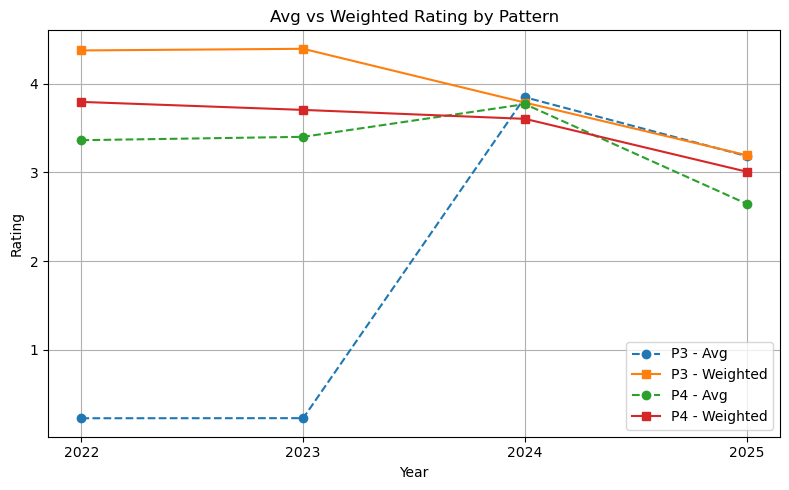

In [62]:
# 선 그래프
plt.figure(figsize=(8, 5))
for pattern in df_filtered["Pattern"].unique():
    subset = df_filtered[df_filtered["Pattern"] == pattern]
    plt.plot(subset["year"], subset["avg_rating"], marker='o', linestyle='--', label=f"{pattern} - Avg")
    plt.plot(subset["year"], subset["weighted_rating"], marker='s', linestyle='-', label=f"{pattern} - Weighted")

plt.title("Avg vs Weighted Rating by Pattern")
plt.xlabel("Year")
plt.ylabel("Rating")
plt.xticks(df_filtered["year"].unique())  # 4자리 연도 고정
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()